#**📈Timeseries and Heatmap Visualization for Extreme Events**

> **Updated** 23-Nov-2025 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will display timeseries of extreme phenomena such as anomalously high temperatures(AHT), heavy rainfall(HR), and marine heatwaves(MHW) for a specific grid point in East Asia.

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Download data**

Create FIRST directories if needed with the following line OR by yourself.

In [ ]:
#!mkdir -p /content/drive/MyDrive/APCC/Data/

Uncomment and run below.

In [ ]:
#!wget --content-disposition "https://www.dropbox.com/scl/fi/pqm64be2s46y8zpq0zn1e/EA1.5_P9095.zip?rlkey=rh8vnut3gzecn4472xycdr0da&st=63cbrbsl&dl=0" -O "/content/drive/MyDrive/APCC/Data/EA1.5_P9095.zip"

Run the following line to unzip the data OR by yourself.

In [ ]:
#!unzip -qq '/content/drive/MyDrive/APCC/Data/EA1.5_P9095.zip' -d '/content/drive/MyDrive/APCC/Data/'

### **Set paths**

CHANGE the following paths if needed!

In [ ]:
PATH_data = "/content/drive/MyDrive/APCC/Data/EA1.5_P9095/"
PATH_save = "/content/drive/MyDrive/APCC/Results/"

### **Import libraries**

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from matplotlib.gridspec import GridSpec
import os
import matplotlib.ticker as mtick
from scipy import stats
import seaborn as sns
from scipy.stats import linregress

### **Set options**

***"You CAN change the target variable, the coordinates, and the start and end dates BELOW."***

In [ ]:
# --- Set options
crt1 = '90'
lat_oi, lon_oi = 36.235774, 127.371063
# lat_oi, lon_oi = 35.076912, 129.869889 # for MHW

sdate, edate = '2024-01-01', '2024-12-31'

### hr
var0 = 'hr'
crt2 = '_D1G3' # _D1G3, _D3G3

# ### aht
# var0 = 'aht'
# crt2 = '_D3G5' # _D5G2, _D3G5

# ### mhw
# var0 = 'mhw'
# crt2 = '_D5G2' # _D5G2, _D3G5

### **Load data**

In [ ]:
# --- Load data
with open(os.path.join(PATH_data, var0+crt1+'.era5.1940-2024.EA1.5.pkl'),'rb') as file:
     data = pickle.load(file)
print(data.keys())

# --- Assign variables
lat, lon  = data['lat'], data['lon']
dates = data['dates']
varname = next(iter(data))
values = data[varname]

# --- Extract threshold and seasonal climatology
thresh = data['clim'+crt1]['thresh']
seas = data['clim'+crt1]['seas']

print('Shape of values:', values.shape)

/tmp/ipython-input-4068902170.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(file)


dict_keys(['tp', 'lat', 'lon', 'dates', 'dates_YM', 'clim90', 'event90_D1G3', 'event90_D3G3', 'ImF90_moving7d', 'EDays90_moving7d', 'IntMx90_moving7d', 'ImF90_mon', 'EDays90_mon', 'IntMx90_mon'])
Shape of values: (31046, 19, 19)


### **Select closest grid point**

In [ ]:
# --- grid point of interest
ly = lat[np.abs(lat - lat_oi).argmin()]
lx = lon[np.abs(lon - lon_oi).argmin()]
ly_,lx_ = str(ly)+'N',str(lx)+'E'
iy, ix = np.argwhere(lat==ly)[0][0], np.argwhere(lon==lx)[0][0]

print('closest lat and lon:', ly, lx)

closest lat and lon: 36.0 127.5


### **Create binary event array**

In [ ]:
# --- Create binary event array using index_start and index_end
events = data['event'+crt1+crt2]
# Initialize binary array with zeros, same size as dates
event_binary = np.zeros(len(dates), dtype=int)

# Get event start and end indices for the specific grid point
start_indices = events['index_start'][ly_, lx_]  # event start indices
end_indices = events['index_end'][ly_, lx_]      # event end indices

# Loop through each event period using indices directly
for start_idx, end_idx in zip(start_indices, end_indices):
    # Set the range from start_idx to end_idx (inclusive) to 1
    event_binary[start_idx:end_idx+1] = 1

print(f"Event binary array created with shape: {event_binary.shape}")
print(f"Total event days: {np.sum(event_binary)}")
print(f"Percentage of event days: {np.sum(event_binary)/len(event_binary)*100:.2f}%")

Event binary array created with shape: (31046,)
Total event days: 4323
Percentage of event days: 13.92%


### **Prepare dataframe for plotting**

In [ ]:
# --- Select point data for entire period
values_pt = values[:,iy,ix]
thresh_pt = np.array(thresh[ly_,lx_])
seas_pt = np.array(seas[ly_,lx_])
df = pd.DataFrame({'date':dates, 'value':values_pt, 'thresh':thresh_pt, 'avg':seas_pt, 'event':event_binary})

# --- Filter by selected date range
df['date'] = pd.to_datetime(df['date'])
mask = (df['date'] >= sdate) & (df['date'] <= edate)
df_selected = df.loc[mask].copy()
dates_selected = df_selected['date']

# --- Adjust units
values_selected = df_selected['value']
thresh_selected = df_selected['thresh']
avg_selected = df_selected['avg']
if var0 == 'hr':
    values_selected *= 1000
    thresh_selected *= 1000
    avg_selected *= 1000
elif var0 == 'aht':
    values_selected -= 273.15
    thresh_selected -= 273.15
    avg_selected -= 273.15

## **Visualization 1. Daily timeseries with extreme events**

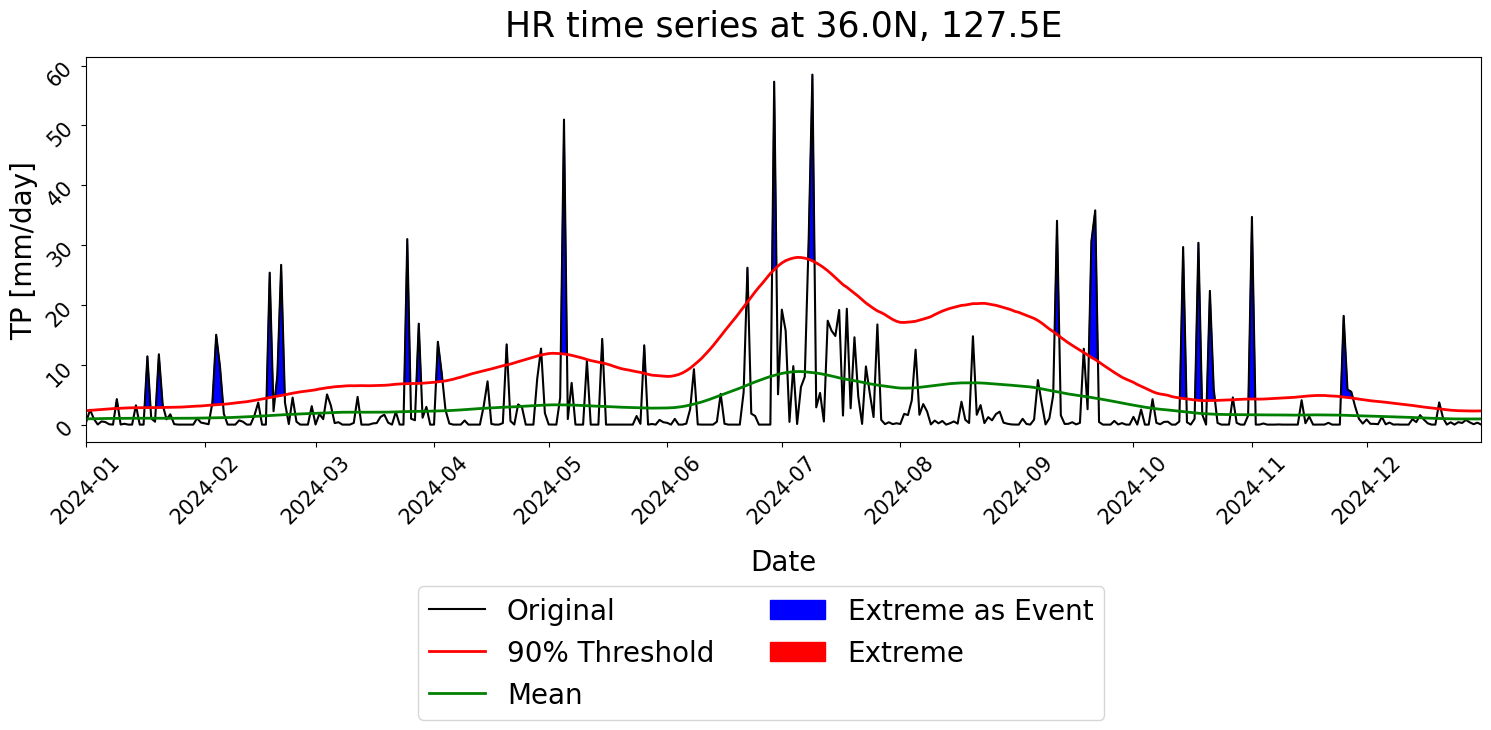

In [ ]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(dates_selected, values_selected, 'k-', linewidth=1.5, label='Original')
ax.plot(dates_selected, thresh_selected, 'r-', linewidth=2, label=f'{crt1}% Threshold')
ax.plot(dates_selected, avg_selected, 'g-', linewidth=2, label='Mean')
ymin, ymax = ax.get_ylim()
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 1),
    color='blue',
    interpolate=True,
    label='Extreme as Event'
)
ax.fill_between(
    df_selected['date'],
    df_selected['value'],
    df_selected['thresh'],
    where=(df_selected['value'] >= df_selected['thresh']) & (df_selected['event'] == 0),
    color='red',
    interpolate=True,
    label='Extreme'
)
ax.set_xlim(dates_selected.min(), dates_selected.max())
ax.set_ylim(ymin, ymax)  # y축 범위 다시 설정
ax.set_ylabel('TP [mm/day]' if var0=='hr' else
              'SST [°C]' if var0=='mhw' else
              'T2m [°C]',
              fontsize=20)
ax.set_xlabel('Date', fontsize=20, labelpad=15)
ax.tick_params(axis='both', which='major', labelsize=15, rotation=45)
ax.set_title(f"{var0.upper()} time series at {ly_}, {lx_}", fontsize=25, pad=15)
# ax.legend(
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     borderaxespad=0,
#     fontsize=18,
# )
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2, fontsize=20)
plt.savefig(os.path.join(PATH_save, f"{var0}{crt1}_daily_extreme_event_timeseries.png"), dpi=100, bbox_inches='tight')
plt.show()

## **Visualization 2. Yearly timeseries with event sums**

Aggregate yearly event sums and calculate linear trend.

In [ ]:
# === Event timeseries
start_period = '1940'
end_period   = '2024'
df['year'] = df['date'].dt.to_period('Y')
df_period = df[(df['year'] >= start_period) & (df['year'] <= end_period)].copy()
df_period.set_index('date', inplace=True)
yearly = df_period['event'].resample('Y').sum()

# Linear regression
years = np.array([d.year for d in yearly.index])
years_norm = years - years.min()
counts = yearly.values
slope, intercept, r_value, p_value, std_err = stats.linregress(years_norm, counts)
trend = intercept + slope * years_norm
eq = f'y = {slope:.2f}x + {intercept:.2f}\nR² = {r_value**2:.3f}'

/tmp/ipython-input-761767416.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly = df_period['event'].resample('Y').sum()


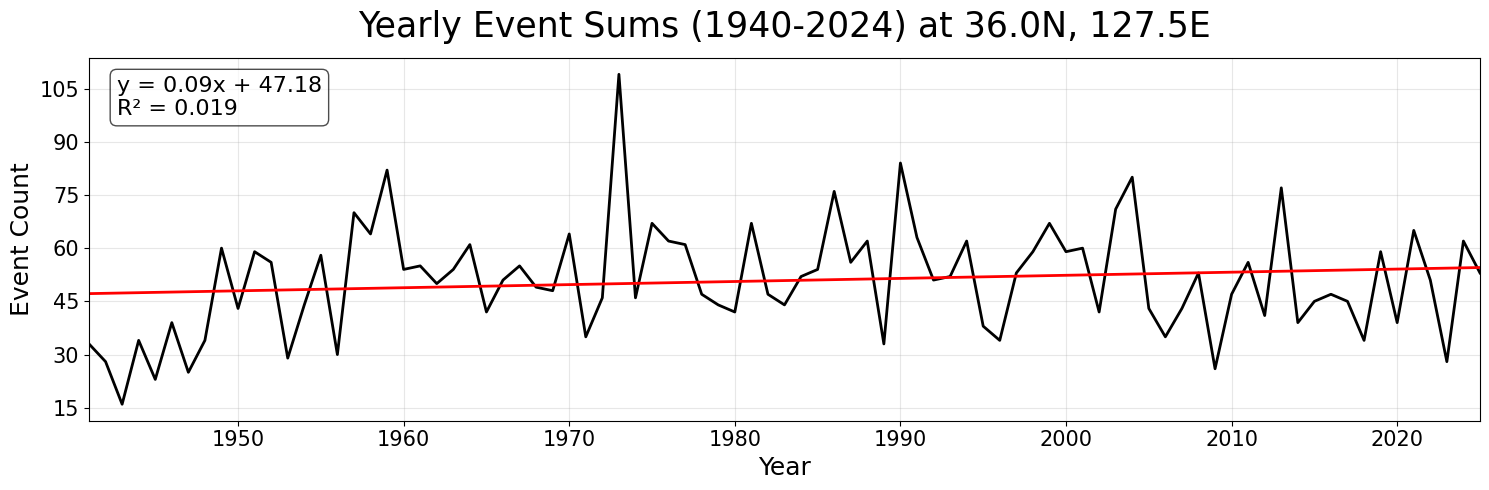

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(yearly.index, yearly.values, color='k', linewidth=2, label='Yearly Sum')
ax.plot(yearly.index, trend, 'r-', linewidth=2, label='Trend Line')
ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Event Count', fontsize=18)
ax.set_title(f'Yearly Event Sums ({start_period}-{end_period}) at {ly_}, {lx_}', fontsize=25, pad=15)
ax.tick_params(axis='both', which='major', labelsize=15)#, rotation=45)
ax.yaxis.set_major_locator(mtick.MaxNLocator(integer=True))
ax.text(0.02, 0.95, eq, transform=ax.transAxes,
        fontsize=16, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax.margins(x=0)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PATH_save, f"{var0}{crt1}{crt2}_yearly_eventsums_timeseries.png"), dpi=100, bbox_inches='tight')
plt.show()

## **Visualization 3. Monthly heatmap with event sums + Trend annotations**

In [ ]:
# === Event timeseries monthly heatmap with trend annotations
start_period = '1940'
end_period   = '2024'

# Ensure date and event columns
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Filter desired period
df_period = df[(df['year'] >= int(start_period)) & (df['year'] <= int(end_period))].copy()

# Group by year and month, summing events
monthly_sum = df_period.groupby(['year', 'month'])['event'].sum().reset_index()

# Pivot to wide format: rows=month, cols=year
heat_df = monthly_sum.pivot(index='month', columns='year', values='event')

# Compute trend (slope) for each month
slopes = {}
years = heat_df.columns.values
years_norm = years - years.min()
for month in heat_df.index:
    counts = heat_df.loc[month].values
    slope, _, _, p_value, _ = linregress(years_norm, counts)
    slopes[month] = slope

# Determine trend direction
trend_label = {m: '(+)' if slopes[m] > 0 else '(–)' if slopes[m] < 0 else '–' for m in heat_df.index}

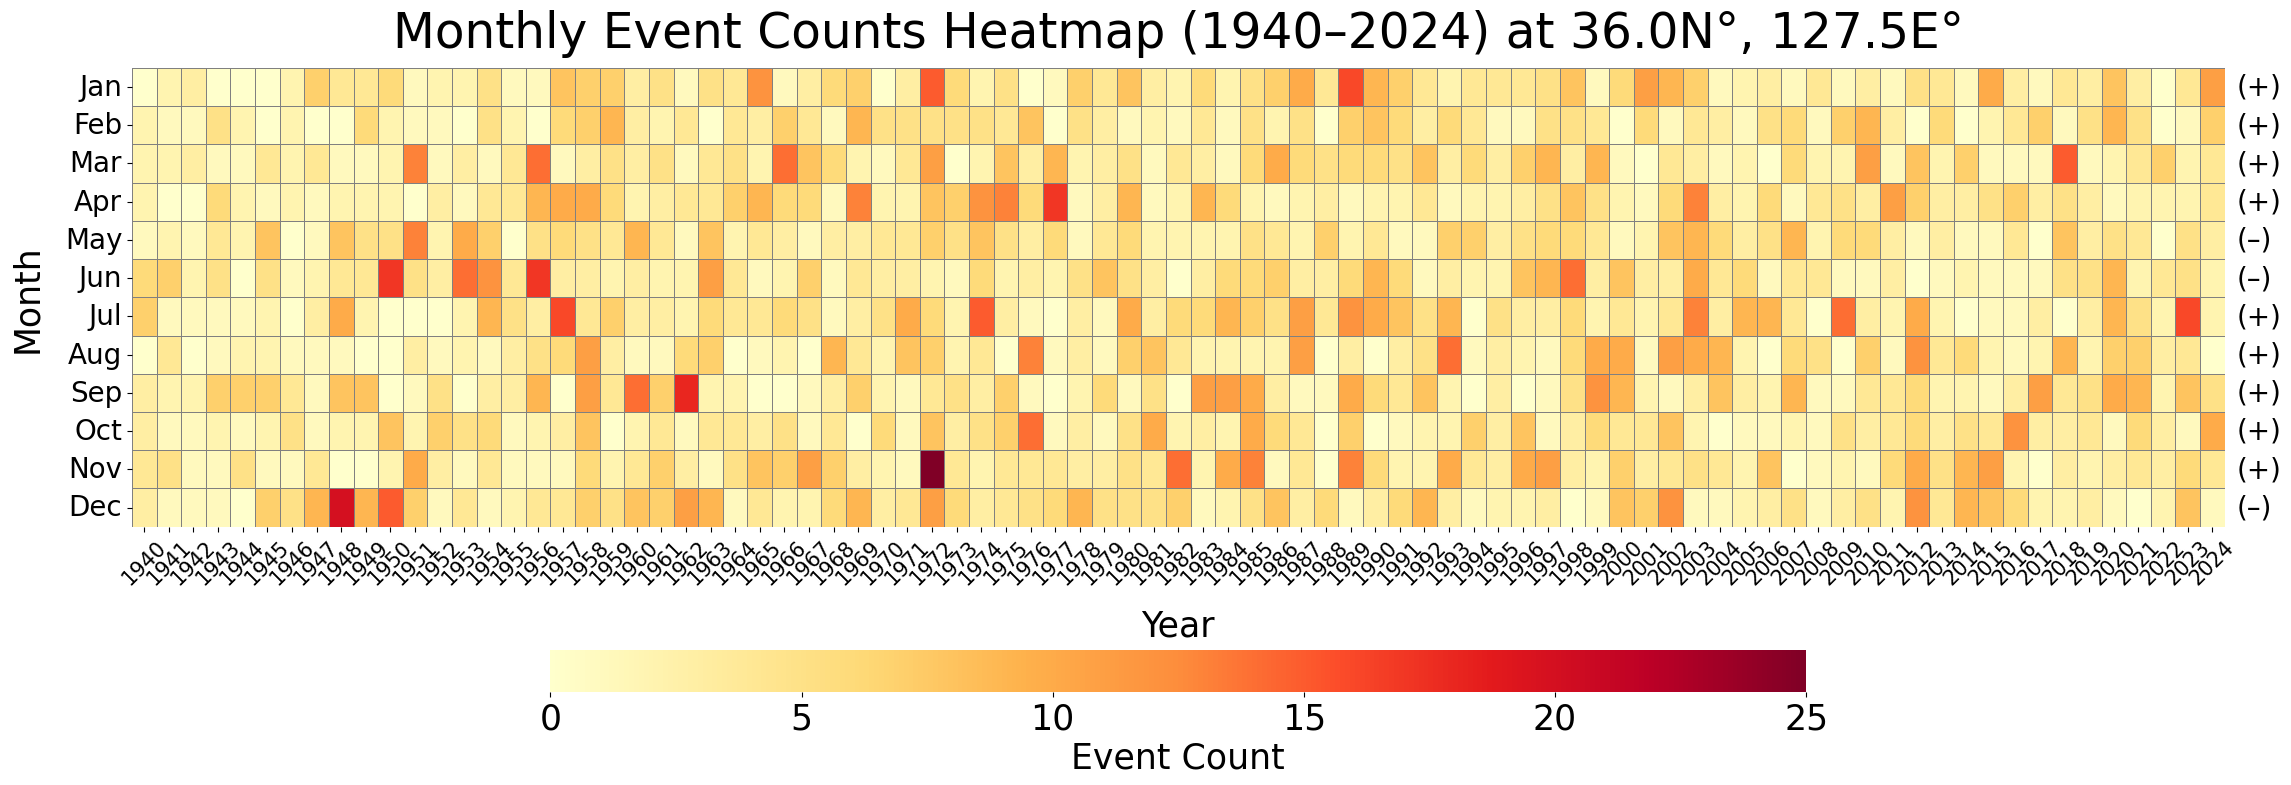

In [ ]:
fig, ax = plt.subplots(figsize=(23, 8))
cbar_kws = {
    'label': 'Event Count',
    'orientation': 'horizontal',
    'pad': 0.18,           # colorbar와 플롯 사이 여백
    'shrink': 0.6,         # colorbar 길이 비율
    'ticks': None,          # 자동 눈금
    'aspect': 30
}
sns.heatmap(
    heat_df,
    cmap='YlOrRd',
    cbar_kws=cbar_kws,
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)   # colorbar tick fontsize
cbar.ax.xaxis.label.set_size(25)    # colorbar label fontsize
ax.set_xlabel('Year', fontsize=25, labelpad=15)
ax.set_ylabel('Month', fontsize=25, labelpad=15)
ax.set_title(f'Monthly Event Counts Heatmap ({start_period}–{end_period}) at {ly_}°, {lx_}°', fontsize=35, pad=15)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(0.5, 12.5))
ax.set_yticklabels(months, rotation=0, fontsize=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=15)
for idx, month in enumerate(heat_df.index):
    ax.text(
        len(years) + 0.5,
        idx + 0.5,
        trend_label[month],
        va='center',
        ha='left',
        fontsize=20
    )
plt.subplots_adjust(right=0.9)
plt.tight_layout()
plt.savefig(os.path.join(PATH_save, f"{var0}{crt1}{crt2}_monthly_eventsums_heatmap.png"), dpi=100, bbox_inches='tight')
plt.show()